   Maturity     Yield
0       0.5  2.800000
1       1.0  2.900000
2       1.5  2.958599
3       2.0  3.000000
4       2.5  3.044040
5       3.0  3.093103
6       3.5  3.145210
7       4.0  3.198382
8       4.5  3.250638
9       5.0  3.300000

Yield Curve Statistics
10Y-2Y Spread: 0.6 %
30Y-10Y Spread: 0.5 %


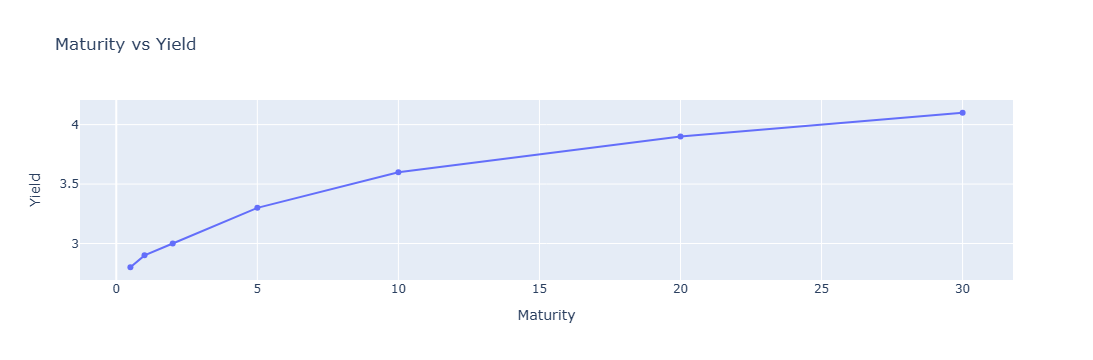

In [8]:
"""
Government Yield Curve Construction
Interpolation and Curve Analysis
"""

import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline


# Government bond yields
curve = pd.DataFrame({
    "Maturity":[0.5,1,2,5,10,20,30],
    "Yield":[2.80,2.90,3.00,3.30,3.60,3.90,4.10]})


# Cubic spline interpolation
spline = CubicSpline(curve["Maturity"],curve["Yield"])

missing_maturities = np.arange(0.5,30,0.5)

interpolated_curve = pd.DataFrame({
    "Maturity":missing_maturities,
    "Yield":spline(missing_maturities)})

print(interpolated_curve.head(10))


# Curve indicators
two_year = spline(2)
ten_year = spline(10)
thirty_year = spline(30)


print("\nYield Curve Statistics")
print("10Y-2Y Spread:",round(ten_year-two_year,3),"%")
print("30Y-10Y Spread:",round(thirty_year-ten_year,3),"%")

"""
if you want the curve to be printed in a csv file

interpolated_curve.to_csv("yield_curve.csv",index=False )
"""

# Create the graph
import plotly.express as px
fig = px.line(
    curve, 
    x='Maturity', 
    y='Yield', 
    title='Maturity vs Yield',
    markers=True)  # This adds dots to the data points)
fig.show()